In [1]:
print('ram ram')

ram ram


In [2]:
# =====================================================================
# 0. INSTALL DEPENDENCIES (Uncomment if needed)
# =====================================================================
# !pip install -q langgraph litellm pydantic sqlalchemy nest_asyncio influxdb-client python-dotenv pyodbc

import asyncio
import os
import operator
from typing import Annotated, Dict, List, Any, TypedDict, Sequence
from typing_extensions import TypedDict

import nest_asyncio
from pydantic import BaseModel, Field
from litellm import Router
from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool

nest_asyncio.apply()

# Verify keys
if not os.getenv("GROQ_API_KEY") or not os.getenv("GEMINI_API_KEY"):
    raise ValueError("Please set GROQ_API_KEY and GEMINI_API_KEY in your environment.")

In [3]:

# =====================================================================
# 1. LITELLM GATEWAY ROUTER (Latency-Based Routing & Fallback)
# =====================================================================
model_list = [
    {
        "model_name": "groq-fast",
        "litellm_params": {
            "model": "groq/openai/gpt-oss-20b",
            "api_key": os.getenv("GROQ_API_KEY"),
            "rpm": 30,
        },
    },
    {
        "model_name": "gemini-fallback",
        "litellm_params": {
            "model": "gemini/gemini-3.8-flash",
            "api_key": os.getenv("GEMINI_API_KEY"),
            "rpm": 60,
        },
    },
]

llm_router = Router(
    model_list=model_list,
    routing_strategy="latency-based-routing",
    fallbacks=[{"groq-fast": ["gemini-fallback"]}],
    num_retries=3,
    timeout=15,
)

async def execute_llm_query(system_prompt: str, user_prompt: str, tools=None) -> str:
    """Simple non-tool LLM call (used by supervisor & aggregator)."""
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    response = await llm_router.acompletion(
        model="groq-fast",
        messages=messages,
        temperature=0.1,
        tools=tools,
    )
    return response.choices[0].message.content or ""

17:49:52 - LiteLLM:WARNING: utils.py:2722 - register_model: model=6d60dc9cb448fba9ceda7d12fe090eaa02d810780db0e4a10178653851b98c99 not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info
17:49:52 - LiteLLM:WARNING: utils.py:2722 - register_model: model=cbeffccbce1d97946e9f3ee60728d0ea9397a7b938913adbb6bfd321c4c4babf not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info


In [4]:
# =====================================================================
# 2. DATABASE CONNECTIONS (your original code)
# =====================================================================
from contextlib import contextmanager
from urllib.parse import quote_plus
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.ext.asyncio import AsyncSession, async_sessionmaker, create_async_engine
from influxdb_client import InfluxDBClient

load_dotenv()

# ---------- 1. MES SQL Server ----------
DB_DRIVER = os.getenv("DB_DRIVER", "ODBC Driver 18 for SQL Server")
DB_SERVER = os.getenv("DB_SERVER", "localhost,1433")
DB_NAME = os.getenv("DB_NAME", "mes_new")
DB_TRUSTED_CONNECTION = os.getenv("DB_TRUSTED_CONNECTION", "yes")
DB_ENCRYPT = os.getenv("DB_ENCRYPT", "no")
DB_TRUST_SERVER_CERTIFICATE = os.getenv("DB_TRUST_SERVER_CERTIFICATE", "yes")

MES_ODBC_CONNECTION = (
    f"DRIVER={{{DB_DRIVER}}};"
    f"SERVER={DB_SERVER};"
    f"DATABASE={DB_NAME};"
    f"Trusted_Connection={DB_TRUSTED_CONNECTION};"
    f"Encrypt={DB_ENCRYPT};"
    f"TrustServerCertificate={DB_TRUST_SERVER_CERTIFICATE};"
)
MES_DATABASE_URL = "mssql+pyodbc:///?odbc_connect=" + quote_plus(MES_ODBC_CONNECTION)

mes_engine = create_engine(MES_DATABASE_URL, pool_pre_ping=True, pool_recycle=1800, future=True)

@contextmanager
def get_mes_connection():
    with mes_engine.connect() as connection:
        yield connection

# ---------- 2. Video Analytics PostgreSQL ----------
CONSTRUCTION_DB_URL = os.getenv("CONSTRUCTION_DB_URL")
if not CONSTRUCTION_DB_URL:
    raise RuntimeError("CONSTRUCTION_DB_URL is missing from .env")

video_engine = create_engine(CONSTRUCTION_DB_URL, pool_pre_ping=True, pool_recycle=1800, future=True)

@contextmanager
def get_video_connection():
    with video_engine.connect() as connection:
        yield connection

# ---------- 3. MAI PostgreSQL (Async) ----------
DATABASE_URL = os.getenv("DATABASE_URL")
if not DATABASE_URL:
    raise RuntimeError("DATABASE_URL is missing from .env")

mai_async_engine = create_async_engine(DATABASE_URL, pool_pre_ping=True, pool_recycle=1800, future=True)
MAIAsyncSessionLocal = async_sessionmaker(bind=mai_async_engine, class_=AsyncSession, expire_on_commit=False)

async def get_mai_session():
    async with MAIAsyncSessionLocal() as session:
        try:
            yield session
        finally:
            await session.close()

# ---------- 4. InfluxDB ----------
INFLUXDB_URL = os.getenv("INFLUXDB_URL")
INFLUXDB_TOKEN = os.getenv("INFLUXDB_TOKEN")
INFLUXDB_ORG = os.getenv("INFLUXDB_ORG")
INFLUXDB_BUCKET = os.getenv("INFLUXDB_BUCKET")

if not all([INFLUXDB_URL, INFLUXDB_TOKEN, INFLUXDB_ORG, INFLUXDB_BUCKET]):
    raise RuntimeError("InfluxDB configuration is incomplete in .env")

influx_client = InfluxDBClient(url=INFLUXDB_URL, token=INFLUXDB_TOKEN, org=INFLUXDB_ORG)
influx_query_api = influx_client.query_api()

def get_influx_query_api():
    return influx_query_api

def close_influx_connection():
    influx_client.close()

In [5]:
# =====================================================================
# 3. SAMPLE TOOLS – 2 tools for each sub-agent
# =====================================================================

# ---------- Influx Agent Tools ----------
@tool
def query_influx_latest(measurement: str = "temperature", hours: int = 1) -> str:
    """Query latest IoT telemetry from InfluxDB for a given measurement."""
    try:
        query = f'''
        from(bucket: "{INFLUXDB_BUCKET}")
          |> range(start: -{hours}h)
          |> filter(fn: (r) => r._measurement == "{measurement}")
          |> last()
        '''
        tables = get_influx_query_api().query(query)
        results = []
        for table in tables:
            for record in table.records:
                results.append(f"{record.get_field()}: {record.get_value()} @ {record.get_time()}")
        return "\n".join(results) if results else "No data found."
    except Exception as e:
        return f"Influx query error: {str(e)}"

@tool
def query_influx_aggregate(measurement: str = "temperature", hours: int = 24, agg: str = "mean") -> str:
    """Aggregate IoT data (mean/max/min) over a time window from InfluxDB."""
    try:
        query = f'''
        from(bucket: "{INFLUXDB_BUCKET}")
          |> range(start: -{hours}h)
          |> filter(fn: (r) => r._measurement == "{measurement}")
          |> aggregateWindow(every: 1h, fn: {agg}, createEmpty: false)
        '''
        tables = get_influx_query_api().query(query)
        results = [f"{r.get_time()}: {r.get_value()}" for table in tables for r in table.records]
        return "\n".join(results[:20]) if results else "No aggregated data."
    except Exception as e:
        return f"Influx aggregate error: {str(e)}"


In [6]:


# ---------- MES Agent Tools ----------
@tool
def query_mes_orders(limit: int = 5) -> str:
    """Fetch recent production orders from MES SQL Server."""
    try:
        with get_mes_connection() as conn:
            # Adjust table/column names to your real schema
            result = conn.execute(text(f"SELECT TOP {limit} * FROM ProductionOrders ORDER BY OrderDate DESC"))
            rows = result.fetchall()
            return "\n".join([str(dict(row._mapping)) for row in rows]) if rows else "No orders found."
    except Exception as e:
        return f"MES orders error: {str(e)}"

@tool
def query_mes_machine_status(machine_id: str = "M001") -> str:
    """Get current status of a machine from MES."""
    try:
        with get_mes_connection() as conn:
            result = conn.execute(
                text("SELECT TOP 1 * FROM MachineStatus WHERE MachineID = :mid ORDER BY Timestamp DESC"),
                {"mid": machine_id}
            )
            row = result.fetchone()
            return str(dict(row._mapping)) if row else f"No status for machine {machine_id}."
    except Exception as e:
        return f"MES machine status error: {str(e)}"



In [7]:

# ---------- Video Analytics Agent Tools ----------
@tool
def query_video_events(hours: int = 24, limit: int = 10) -> str:
    """Fetch recent video analytics events (safety, PPE, etc.)."""
    try:
        with get_video_connection() as conn:
            # Adjust table name to your schema
            result = conn.execute(
                text(f"""
                    SELECT * FROM video_events 
                    WHERE event_time > NOW() - INTERVAL '{hours} hours'
                    ORDER BY event_time DESC LIMIT {limit}
                """)
            )
            rows = result.fetchall()
            return "\n".join([str(dict(row._mapping)) for row in rows]) if rows else "No video events."
    except Exception as e:
        return f"Video events error: {str(e)}"

@tool
def query_video_camera_status(camera_id: str = "CAM01") -> str:
    """Get status / last activity of a specific camera."""
    try:
        with get_video_connection() as conn:
            result = conn.execute(
                text("""
                    SELECT * FROM camera_status 
                    WHERE camera_id = :cid 
                    ORDER BY last_seen DESC LIMIT 1
                """),
                {"cid": camera_id}
            )
            row = result.fetchone()
            return str(dict(row._mapping)) if row else f"No data for camera {camera_id}."
    except Exception as e:
        return f"Camera status error: {str(e)}"



In [8]:

# Collect tools
influx_tools = [query_influx_latest, query_influx_aggregate]
mes_tools = [query_mes_orders, query_mes_machine_status]
video_tools = [query_video_events, query_video_camera_status]

In [9]:
# =====================================================================
# 4. STATE & HELPER FOR TOOL-CALLING AGENTS
# =====================================================================
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    # Optional: keep track of which agents have finished
    next: str


async def call_llm_with_tools(system_prompt: str, messages: list, tools: list):
    """Convert LangChain messages → LiteLLM format and handle tool calls."""
    litellm_messages = [{"role": "system", "content": system_prompt}]
    for m in messages:
        if isinstance(m, HumanMessage):
            litellm_messages.append({"role": "user", "content": m.content})
        elif isinstance(m, AIMessage):
            litellm_messages.append({"role": "assistant", "content": m.content or ""})
        elif isinstance(m, ToolMessage):
            litellm_messages.append({
                "role": "tool",
                "tool_call_id": m.tool_call_id,
                "content": m.content
            })

    # Convert tools to OpenAI format
    openai_tools = [
        {
            "type": "function",
            "function": {
                "name": t.name,
                "description": t.description,
                "parameters": t.args_schema.schema() if hasattr(t, "args_schema") else {},
            }
        }
        for t in tools
    ]

    response = await llm_router.acompletion(
        model="groq-fast",
        messages=litellm_messages,
        tools=openai_tools,
        temperature=0.1,
    )

    msg = response.choices[0].message
    if msg.tool_calls:
        # Return AIMessage with tool_calls so ToolNode can process them
        return AIMessage(
            content=msg.content or "",
            tool_calls=[
                {
                    "name": tc.function.name,
                    "args": eval(tc.function.arguments) if isinstance(tc.function.arguments, str) else tc.function.arguments,
                    "id": tc.id,
                }
                for tc in msg.tool_calls
            ]
        )
    return AIMessage(content=msg.content or "")

In [10]:
# =====================================================================
# 5. AGENT NODES
# =====================================================================

# ---------- Supervisor ----------
async def supervisor_node(state: AgentState):
    system = """You are the Supervisor. Your job is to understand the user request and decide which specialist agents to call.
Available agents:
- influx_agent : IoT / sensor / telemetry data
- mes_agent : Manufacturing Execution System (orders, machines)
- video_analytics_agent : Camera / safety / PPE events

Reply with a short plan and then just say "ROUTE" so the graph can fan-out.
"""
    user_msg = state["messages"][-1].content if state["messages"] else "No query"
    reply = await execute_llm_query(system, user_msg)
    return {"messages": [AIMessage(content=reply)], "next": "fanout"}


# ---------- Influx Agent ----------
async def influx_agent_node(state: AgentState):
    system = """You are the Influx Agent. You have tools to query IoT telemetry.
Use the tools when needed. Answer concisely with the data you find."""
    response = await call_llm_with_tools(system, state["messages"], influx_tools)
    return {"messages": [response]}


# ---------- MES Agent ----------
async def mes_agent_node(state: AgentState):
    system = """You are the MES Agent. You have tools to query production orders and machine status.
Use the tools when needed. Answer concisely."""
    response = await call_llm_with_tools(system, state["messages"], mes_tools)
    return {"messages": [response]}


# ---------- Video Analytics Agent ----------
async def video_agent_node(state: AgentState):
    system = """You are the Video Analytics Agent. You have tools for camera events and status.
Use the tools when needed. Answer concisely."""
    response = await call_llm_with_tools(system, state["messages"], video_tools)
    return {"messages": [response]}


# ---------- Canvas Aggregator ----------
async def canvas_aggregator_node(state: AgentState):
    system = """You are the Canvas Aggregator. You receive results from influx_agent, mes_agent and video_analytics_agent.
Combine them into a single coherent, well-structured final answer for the user.
Do not invent data."""
    # Take the last few messages (the agents' replies)
    recent = "\n\n".join([m.content for m in state["messages"][-6:] if m.content])
    final = await execute_llm_query(system, f"Agent results:\n{recent}")
    return {"messages": [AIMessage(content=final)]}

Graph compiled successfully!


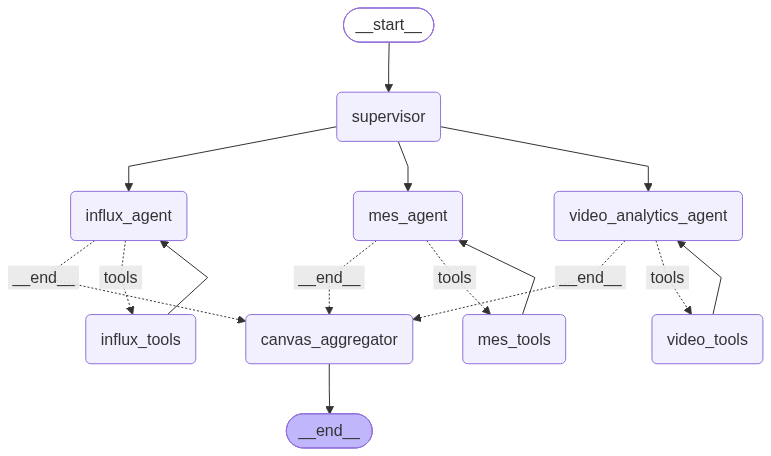

In [11]:
# =====================================================================
# 6. BUILD THE LANGGRAPH  (FIXED)
# =====================================================================
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("supervisor", supervisor_node)
workflow.add_node("influx_agent", influx_agent_node)
workflow.add_node("mes_agent", mes_agent_node)
workflow.add_node("video_analytics_agent", video_agent_node)   # correct name
workflow.add_node("canvas_aggregator", canvas_aggregator_node)

# Tool nodes
workflow.add_node("influx_tools", ToolNode(influx_tools))
workflow.add_node("mes_tools", ToolNode(mes_tools))
workflow.add_node("video_tools", ToolNode(video_tools))

# Edges
workflow.add_edge(START, "supervisor")

# Supervisor fans out to the three agents
workflow.add_edge("supervisor", "influx_agent")
workflow.add_edge("supervisor", "mes_agent")
workflow.add_edge("supervisor", "video_analytics_agent")

# Influx agent + tools loop
workflow.add_conditional_edges(
    "influx_agent",
    tools_condition,
    {"tools": "influx_tools", END: "canvas_aggregator"}
)
workflow.add_edge("influx_tools", "influx_agent")

# MES agent + tools loop
workflow.add_conditional_edges(
    "mes_agent",
    tools_condition,
    {"tools": "mes_tools", END: "canvas_aggregator"}
)
workflow.add_edge("mes_tools", "mes_agent")

# Video agent + tools loop  ← FIXED HERE
workflow.add_conditional_edges(
    "video_analytics_agent",
    tools_condition,
    {"tools": "video_tools", END: "canvas_aggregator"}
)
workflow.add_edge("video_tools", "video_analytics_agent")   # ← was "video_agent" (typo)

# Aggregator → END
workflow.add_edge("canvas_aggregator", END)

# Compile
app = workflow.compile()
print("Graph compiled successfully!")
app

In [12]:
# # =====================================================================
# # 8. RUN EXAMPLE
# # =====================================================================
# async def run_query(query: str):
#     initial_state = {
#         "messages": [HumanMessage(content=query)],
#         "next": ""
#     }
#     result = await app.ainvoke(initial_state)
    
#     print("=" * 60)
#     print("FINAL ANSWER FROM CANVAS AGGREGATOR:")
#     print("=" * 60)
#     print(result["messages"][-1].content)
#     return result

# # Example
# await run_query("Give me the latest temperature from IoT, recent production orders, and any safety events from cameras in the last 24 hours.")